# LULC Classification: Model Training Pipeline
**Project:** Multispectral Image Analysis & Uncertainty Quantification  
**Author:** Danesh Selwal  
**Date:** 2026-05-02

---
## Executive Summary
This notebook trains core neural architectures for multispectral LULC classification and stores model artifacts for downstream uncertainty analysis.

**Objective:**
Train, validate, and compare baseline models (Accuracy, Kappa, F1), then export best checkpoints for post-training uncertainty workflows.

---
## 1. Environment Setup & Configuration
Import dependencies, mount storage when needed, and define global configuration and reproducibility controls.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import sys

MODULE_NAME = 'ensemble'
REPO_ROOT = Path("/content/drive/MyDrive/dias_uncertainty_quantification")
MODULE_DIR = REPO_ROOT / MODULE_NAME
RESULTS_DIR = MODULE_DIR / 'results'
MODELS_DIR = MODULE_DIR / 'models'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Module: {MODULE_NAME}')
print(f'Output Directory: {RESULTS_DIR}')


In [1]:
from pathlib import Path





Mounted at /content/drive


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow C++ INFO/WARNING logs
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    f1_score,
    log_loss,
)

sns.set_style("whitegrid")
print("TensorFlow:", tf.__version__)





TensorFlow: 2.19.0


In [3]:
# -----------------------------
# Configuration
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = REPO_ROOT
DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = MODELS_DIR
PLOT_DIR = RESULTS_DIR / "training_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "DIAS.mat"
LABEL_FILE = DATA_DIR / "DIAS_ref.mat"

# Dataset geometry for current 6-band data
H, W, B = 330, 307, 6
PATCH_SIZE = 9
INNER_PATCH = 3  # used by GFNet/ViT tokenization
TRAIN_PERCENT = 0.75
VAL_SPLIT_FROM_TRAIN = 0.20

BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 3e-4
DROPOUT_RATE = 0.25

# Legacy architecture configs (aligned to original single-head notebooks)
CAPACITY_PRESET = "legacy_arch"
ALEXNET_CFG = {
    "conv_filters": [96, 256, 384, 384, 256],
    "dense_units": [4096, 1024, 256, 32],
}
GFNET_CFG = {
    "hidden_dim": 512,
    "num_blocks": 5,
    "mlp_ratio": 4,
}
VIT_CFG = {
    "projection_dim": 256,
    "num_heads": 4,
    "transformer_layers": 12,
    "mlp_multiplier": 2,
    "head_units": [512, 256, 128, 64],
}

# Deterministic fallback if Colab runs out of memory
GFNET_FALLBACK_CFG = {
    "hidden_dim": 384,
    "num_blocks": 4,
    "mlp_ratio": 4,
}
VIT_FALLBACK_CFG = {
    "projection_dim": 192,
    "num_heads": 4,
    "transformer_layers": 8,
    "mlp_multiplier": 2,
    "head_units": [384, 192, 96, 64],
}

# Keep training policy unchanged
TRAIN_CFG = {
    "label_smoothing": 0.05,
    "weight_decay": 1e-4,
    "clipnorm": 1.0,
    "cosine_alpha": 0.05,
}

print("Data file:", DATA_FILE)
print("Label file:", LABEL_FILE)
print("Model save dir:", MODEL_DIR)
print("Plot save dir:", PLOT_DIR)
print("Architecture preset:", CAPACITY_PRESET)

# AlexNet legacy-recipe controls (for uncertainty recovery)
ALEXNET_LEGACY_SPLIT_SEED = 10
ALEXNET_LEGACY_TRAIN_PERCENT = 0.75
ALEXNET_LR_START = 0.01
ALEXNET_LR_MAX = 0.02
ALEXNET_LR_MIN = 0.005





Data file: /content/drive/My Drive/m_p/data/multispectral/data.csv
Label file: /content/drive/My Drive/m_p/data/multispectral/ref.csv
Model save dir: /content/drive/My Drive/m_p/saved_models
Plot save dir: /content/drive/My Drive/m_p/saved_models/training_plots
Architecture preset: legacy_arch


## 2. Data Ingestion & Preprocessing
Load multispectral inputs and reference labels, apply normalization, and prepare patch-based tensors for model training/evaluation.


In [4]:

# -----------------------------
# Data loading and patch extraction
# -----------------------------
def extract_labeled_patches(x, y, patch_size=9):
    pad = patch_size // 2
    x_pad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="edge")

    coords = np.argwhere(y > 0)
    patches = np.empty((coords.shape[0], patch_size, patch_size, x.shape[-1]), dtype=np.float32)
    labels = np.empty((coords.shape[0],), dtype=np.int32)

    for i, (r, c) in enumerate(coords):
        patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        labels[i] = int(y[r, c]) - 1  # convert class IDs to 0..C-1

    return patches, labels, coords



# -----------------------------
# Generalized Data Loading
# -----------------------------
import scipy.io as sio
import pandas as pd
import numpy as np

def universal_load_data(data_path, label_path):
    data_path = str(data_path)
    label_path = str(label_path)
    
    # Load features
    if data_path.endswith('.mat'):
        mat = sio.loadmat(data_path)
        x = next(v for k, v in mat.items() if not k.startswith('__') and isinstance(v, np.ndarray))
    elif data_path.endswith('.csv'):
        x = pd.read_csv(data_path).to_numpy(dtype=np.float32)
    elif data_path.endswith(('.tif', '.tiff')):
        try:
            import rasterio
            with rasterio.open(data_path) as src:
                x = src.read()
                x = np.moveaxis(x, 0, -1)
        except ImportError:
            print("rasterio not installed. Using dummy data.")
            x = np.zeros((10,10,3))

    # Load labels
    if label_path.endswith('.mat'):
        lmat = sio.loadmat(label_path)
        y = next(v for k, v in lmat.items() if not k.startswith('__') and isinstance(v, np.ndarray))
    elif label_path.endswith('.csv'):
        y = pd.read_csv(label_path).to_numpy(dtype=np.int32)
    elif label_path.endswith(('.tif', '.tiff')):
        try:
            import rasterio
            with rasterio.open(label_path) as src:
                y = src.read(1)
        except ImportError:
            y = np.zeros((10,10))

    # Normalization for 3D tensors
    if len(x.shape) == 3:
        x_norm = np.empty_like(x, dtype=np.float32)
        for b_idx in range(x.shape[-1]):
            band = x[:, :, b_idx]
            b_min, b_max = np.min(band), np.max(band)
            x_norm[:, :, b_idx] = (band - b_min) / max(b_max - b_min, 1e-8)
        x = x_norm
        
    return x, y

# Apply Generalized Loader
x_img, y_img = universal_load_data(DATA_FILE, LABEL_FILE)

# Handle flat CSVs by requesting user input or fallback
if len(x_img.shape) == 3:
    H, W, B = x_img.shape
else:
    print("WARNING: Data is flat. Please manually reshape x_img and y_img, then define H, W, B.")
    H, W, B = 330, 307, 6 # Default fallback for flat data

num_classes = int(np.unique(y_img).size)
print(f"Loaded Data Shape: {x_img.shape}, Labels Shape: {y_img.shape}, Classes: {num_classes}")

# Dynamic Color Palette Setup
import seaborn as sns
from matplotlib.colors import ListedColormap
BACKGROUND_COLOR = "#000000"
CLASS_COLOR_BASE = sns.color_palette("hls", max(10, num_classes)).as_hex()
X, y, coords = extract_labeled_patches(x_img, y_img, PATCH_SIZE)

num_classes = int(np.unique(y).size)
input_shape = (PATCH_SIZE, PATCH_SIZE, B)

print("x_img:", x_img.shape, "y_img:", y_img.shape)
print("Labeled samples:", X.shape[0])
print("Patch tensor:", X.shape)
print("Num classes:", num_classes)





x_img: (330, 307, 6) y_img: (330, 307)
Labeled samples: 17239
Patch tensor: (17239, 9, 9, 6)
Num classes: 7


In [5]:

# -----------------------------
# Train/val/test split
# -----------------------------
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_PERCENT,
    random_state=SEED,
    stratify=y,
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=VAL_SPLIT_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_full,
)

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Train:", x_train.shape, y_train.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)


# AlexNet legacy split (matches old single-head script behavior)
x_train_alex, x_test_alex, y_train_alex, y_test_alex = train_test_split(
    X,
    y,
    train_size=ALEXNET_LEGACY_TRAIN_PERCENT,
    random_state=ALEXNET_LEGACY_SPLIT_SEED,
    stratify=y,
)

y_train_alex_cat = keras.utils.to_categorical(y_train_alex, num_classes)
y_test_alex_cat = keras.utils.to_categorical(y_test_alex, num_classes)

print('AlexNet Train/Test:', x_train_alex.shape, y_train_alex.shape, x_test_alex.shape, y_test_alex.shape)





Train: (10343, 9, 9, 6) (10343,)
Val: (2586, 9, 9, 6) (2586,)
Test: (4310, 9, 9, 6) (4310,)
AlexNet Train/Test: (12929, 9, 9, 6) (12929,) (4310, 9, 9, 6) (4310,)


## Model Definitions

In [6]:
# -----------------------------
# 1) AlexNet-based CNN (single-head, legacy architecture)
# -----------------------------
def build_alexnet(input_shape, num_classes, dropout_rate=0.25, cfg=None):
    cfg = cfg or ALEXNET_CFG

    inputs = keras.Input(shape=input_shape)
    x = inputs

    for i, filters in enumerate(cfg["conv_filters"], start=1):
        x = layers.Conv2D(filters, (3, 3), activation="relu", padding="same", name=f"alex_conv_{i}")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same", name="alex_pool")(x)

    dense_units = cfg["dense_units"]
    x = layers.Flatten(name="alex_flatten")(x)
    x = layers.Dense(dense_units[0], activation="relu", name="alex_fc1")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)
    x = layers.Dense(dense_units[1], activation="relu", name="alex_fc2")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(x)
    x = layers.Dense(dense_units[2], activation="relu", name="alex_fc3")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)
    x = layers.Dense(dense_units[3], activation="relu", name="alex_fc4")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="alex_logits")(x)
    return keras.Model(inputs, outputs, name="AlexNet_SingleHead")




In [7]:
# -----------------------------
# 2) Global Filter Network (single-head, legacy architecture)
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        batch = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return cfg


@tf.keras.utils.register_keras_serializable()
class GlobalFilterLayer(layers.Layer):
    def __init__(self, token_side, **kwargs):
        super().__init__(**kwargs)
        self.token_side = token_side

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.w_real = self.add_weight(
            name="w_real",
            shape=(self.token_side, self.token_side, channels),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.w_imag = self.add_weight(
            name="w_imag",
            shape=(self.token_side, self.token_side, channels),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        batch = tf.shape(x)[0]
        channels = tf.shape(x)[-1]
        x_2d = tf.reshape(x, [batch, self.token_side, self.token_side, channels])
        x_fft = tf.signal.fft2d(tf.cast(x_2d, tf.complex64))
        w_complex = tf.complex(self.w_real, self.w_imag)
        x_filtered = x_fft * w_complex
        x_spatial = tf.math.real(tf.signal.ifft2d(x_filtered))
        return tf.reshape(x_spatial, [batch, self.token_side * self.token_side, channels])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"token_side": self.token_side})
        return cfg


def gf_block(x, token_side, dim, mlp_ratio=4, dropout_rate=0.25, name_prefix="gf"):
    # Legacy block style: one residual add after filter + MLP branch.
    y = layers.LayerNormalization(name=f"{name_prefix}_ln1")(x)
    y = GlobalFilterLayer(token_side, name=f"{name_prefix}_gfilter")(y)
    y = layers.LayerNormalization(name=f"{name_prefix}_ln2")(y)
    y = layers.Dense(dim * mlp_ratio, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(y)
    y = layers.Dense(dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(y)
    return layers.Add(name=f"{name_prefix}_add")([x, y])


def build_gfnet(
    input_shape,
    num_classes,
    inner_patch=3,
    hidden_dim=512,
    num_blocks=5,
    mlp_ratio=4,
    dropout_rate=0.25,
):
    num_patches = (input_shape[0] // inner_patch) * (input_shape[1] // inner_patch)
    token_side = int(np.sqrt(num_patches))

    inputs = keras.Input(shape=input_shape)
    x = PatchExtractor(inner_patch, name="gf_patch_extractor")(inputs)
    x = PatchPositionEncoder(num_patches, hidden_dim, name="gf_patch_encoder")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)

    for i in range(num_blocks):
        x = gf_block(x, token_side, hidden_dim, mlp_ratio, dropout_rate, name_prefix=f"gf_block_{i+1}")

    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(x)
    x = layers.LayerNormalization(name="gf_final_ln")(x)
    x = layers.GlobalAveragePooling1D(name="gf_gap")(x)
    x = layers.Flatten(name="gf_flatten")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="gf_logits")(x)

    return keras.Model(inputs, outputs, name="GFNet_SingleHead")




In [8]:
# -----------------------------
# 3) Vision Transformer (single-head, U-Net style skip flow, legacy architecture)
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class PatchEncoderWithCLS(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim)

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.projection_dim),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, patches):
        batch = tf.shape(patches)[0]
        patch_proj = self.projection(patches)
        cls_tokens = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls_tokens, patch_proj], axis=1)
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return cfg


def transformer_block(x, num_heads, projection_dim, mlp_dim, dropout_rate, name_prefix):
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    y = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout_rate,
        name=f"{name_prefix}_mha",
    )(y, y)
    x = layers.Add(name=f"{name_prefix}_add1")([y, x])

    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(x)
    y = layers.Dense(mlp_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(y)
    y = layers.Dense(projection_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(y)
    return layers.Add(name=f"{name_prefix}_add2")([y, x])


def build_vit_unet_singlehead(
    input_shape,
    num_classes,
    inner_patch=3,
    projection_dim=256,
    num_heads=4,
    transformer_layers=12,
    mlp_multiplier=2,
    dropout_rate=0.25,
    head_units=(512, 256, 128, 64),
):
    num_patches = (input_shape[0] // inner_patch) * (input_shape[1] // inner_patch)

    inputs = keras.Input(shape=input_shape)
    x = PatchExtractor(inner_patch, name="vit_patch_extractor")(inputs)
    x = PatchEncoderWithCLS(num_patches, projection_dim, name="vit_patch_encoder")(x)

    block_list = []
    for i in range(transformer_layers):
        x = transformer_block(
            x,
            num_heads=num_heads,
            projection_dim=projection_dim,
            mlp_dim=projection_dim * mlp_multiplier,
            dropout_rate=0.1,
            name_prefix=f"vit_block_{i+1}",
        )

        if i <= transformer_layers // 2:
            block_list.append(x)
        else:
            x = layers.Add(name=f"vit_skip_add_{i+1}")([x, block_list[transformer_layers - i - 1]])

    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="vit_cls_norm")(x)
    cls_token = layers.Lambda(lambda t: t[:, 0, :], name="vit_cls_token")(x)

    y = layers.Dense(head_units[0], activation=tf.keras.activations.gelu, name="vit_head_1")(cls_token)
    y = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(y)
    y = layers.Dense(head_units[1], activation=tf.keras.activations.gelu, name="vit_head_2")(y)
    y = layers.Dense(head_units[2], activation=tf.keras.activations.gelu, name="vit_head_3")(y)
    y = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_5")(y)
    y = layers.Dense(head_units[3], activation=tf.keras.activations.gelu, name="vit_head_4")(y)
    y = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_6")(y)

    outputs = layers.Dense(num_classes, activation="softmax", name="vit_logits")(y)
    return keras.Model(inputs, outputs, name="ViT_UNet_SingleHead")




## Train, Save, and Evaluate

In [9]:
# -----------------------------
# Training and evaluation helpers
# -----------------------------
def multiclass_brier_score(y_onehot, y_prob):
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def expected_calibration_error(y_true, y_prob, n_bins=15):
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    correct = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            in_bin = (confidences >= lo) & (confidences <= hi)
        else:
            in_bin = (confidences >= lo) & (confidences < hi)
        prop = np.mean(in_bin)
        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidences[in_bin])
            ece += np.abs(acc_bin - conf_bin) * prop
    return float(ece)


def make_optimizer(num_train_samples):
    steps_per_epoch = int(np.ceil(num_train_samples / BATCH_SIZE))
    decay_steps = max(1, steps_per_epoch * EPOCHS)
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=decay_steps,
        alpha=TRAIN_CFG["cosine_alpha"],
    )
    optimizer = keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=TRAIN_CFG["weight_decay"],
        clipnorm=TRAIN_CFG["clipnorm"],
    )
    return optimizer


def _alexnet_legacy_lr(epoch):
    # old-script cosine style between [ALEXNET_LR_MIN, ALEXNET_LR_MAX]
    if EPOCHS <= 1:
        return ALEXNET_LR_START
    phase = np.pi * epoch / (EPOCHS - 1)
    cosine_decay = 0.5 * (1.0 + np.cos(phase))
    return float((ALEXNET_LR_MAX - ALEXNET_LR_MIN) * cosine_decay + ALEXNET_LR_MIN)


def train_save_evaluate(model_name, model_builder, capacity_tag="max"):
    tf.keras.backend.clear_session()

    model = model_builder()
    best_path = MODEL_DIR / f"{model_name}_best.keras"
    final_path = MODEL_DIR / f"{model_name}_final.keras"

    # AlexNet-specific legacy recipe for uncertainty recovery
    if model_name == "AlexNet_CNN":
        model.compile(
            optimizer=keras.optimizers.Adagrad(learning_rate=ALEXNET_LR_START),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=str(best_path),
                monitor="val_accuracy",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            keras.callbacks.LearningRateScheduler(_alexnet_legacy_lr, verbose=0),
        ]

        x_tr, y_tr = x_train_alex, y_train_alex
        x_va, y_va = x_test_alex, y_test_alex
        x_te, y_te, y_te_cat = x_test_alex, y_test_alex, y_test_alex_cat
        x_eval_for_metrics, y_eval_for_metrics, y_eval_for_metrics_cat = x_test_alex, y_test_alex, y_test_alex_cat
        fit_shuffle = False

    else:
        # Keep GFNet/ViT path unchanged
        model.compile(
            optimizer=make_optimizer(len(x_train)),
            loss=keras.losses.CategoricalCrossentropy(label_smoothing=TRAIN_CFG["label_smoothing"]),
            metrics=["accuracy"],
        )

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=str(best_path),
                monitor="val_loss",
                mode="min",
                save_best_only=True,
                verbose=1,
            ),
        ]

        x_tr, y_tr = x_train, y_train_cat
        x_va, y_va = x_val, y_val_cat
        x_te, y_te, y_te_cat = x_test, y_test, y_test_cat
        x_eval_for_metrics, y_eval_for_metrics, y_eval_for_metrics_cat = x_val, y_val, y_val_cat
        fit_shuffle = True

    train_start = time.perf_counter()
    history_obj = model.fit(
        x_tr,
        y_tr,
        validation_data=(x_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=fit_shuffle,
    )
    train_time_sec = float(time.perf_counter() - train_start)

    epochs_ran = int(len(history_obj.history.get("loss", [])))
    if epochs_ran != EPOCHS:
        print(
            f"WARNING: {model_name} ran {epochs_ran} epochs, expected {EPOCHS}. "
            "Check runtime interruptions or execution errors."
        )
    else:
        print(f"{model_name} completed full training: {epochs_ran}/{EPOCHS} epochs.")

    model.save(final_path)

    y_eval_prob = model.predict(x_eval_for_metrics, batch_size=BATCH_SIZE, verbose=0)
    y_eval_pred = np.argmax(y_eval_prob, axis=1)

    y_test_prob = model.predict(x_te, batch_size=BATCH_SIZE, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    report = classification_report(y_te, y_test_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_te, y_test_pred)

    row = {
        "model": model_name,
        "capacity_tag": capacity_tag,
        "test_accuracy": float(accuracy_score(y_te, y_test_pred)),
        "kappa": float(cohen_kappa_score(y_te, y_test_pred)),
        "macro_f1": float(f1_score(y_te, y_test_pred, average="macro")),
        "weighted_f1": float(f1_score(y_te, y_test_pred, average="weighted")),
        "val_nll": float(log_loss(y_eval_for_metrics, y_eval_prob, labels=np.arange(num_classes))),
        "test_nll": float(log_loss(y_te, y_test_prob, labels=np.arange(num_classes))),
        "val_brier": multiclass_brier_score(y_eval_for_metrics_cat, y_eval_prob),
        "test_brier": multiclass_brier_score(y_te_cat, y_test_prob),
        "test_ece_15bin": expected_calibration_error(y_te, y_test_prob, n_bins=15),
        "epochs_configured": int(EPOCHS),
        "epochs_ran": epochs_ran,
        "train_time_sec": train_time_sec,
        "best_model_path": str(best_path),
        "final_model_path": str(final_path),
    }

    return row, report, cm, history_obj.history




In [10]:
# -----------------------------
# Train all three single-head models (Ensemble M=5) [FIXED VERSION]
# -----------------------------
import os
import shutil

def build_gfnet_with_cfg(cfg):
    return build_gfnet(
        input_shape,
        num_classes,
        inner_patch=INNER_PATCH,
        hidden_dim=cfg["hidden_dim"],
        num_blocks=cfg["num_blocks"],
        mlp_ratio=cfg["mlp_ratio"],
        dropout_rate=DROPOUT_RATE,
    )

def build_vit_with_cfg(cfg):
    return build_vit_unet_singlehead(
        input_shape,
        num_classes,
        inner_patch=INNER_PATCH,
        projection_dim=cfg["projection_dim"],
        num_heads=cfg["num_heads"],
        transformer_layers=cfg["transformer_layers"],
        mlp_multiplier=cfg["mlp_multiplier"],
        dropout_rate=DROPOUT_RATE,
        head_units=tuple(cfg["head_units"]),
    )

model_builders = {
    "AlexNet_CNN": lambda: build_alexnet(
        input_shape,
        num_classes,
        dropout_rate=DROPOUT_RATE,
        cfg=ALEXNET_CFG,
    ),
    "GFNet": lambda: build_gfnet_with_cfg(GFNET_CFG),
    "ViT_UNet": lambda: build_vit_with_cfg(VIT_CFG),
}

# 🔥 LOCAL SAVE DIRECTORY (fix for Drive crash)
local_dir = Path("/content/local_module_models")
local_dir.mkdir(parents=True, exist_ok=True)

# Google Drive destination
ensemble_dir = MODEL_DIR / "ensembles"
ensemble_dir.mkdir(parents=True, exist_ok=True)

M = 5
results_rows = []
model_artifacts = {}

for model_name, builder in model_builders.items():
    if model_name != "ViT_UNet":   # 🔥 change this to the one you want
        continue
    print(f"\n{'=' * 25} Training {model_name} Ensembles (M={M}) {'=' * 25}")

    for i in range(1, M + 1):
        print(f"\n--- {model_name} Ensemble Model {i}/{M} ---")

        # Seed control
        seed_val = 42 + i
        tf.random.set_seed(seed_val)
        np.random.seed(seed_val)
        random.seed(seed_val)

        tf.keras.backend.clear_session()

        # Build model
        try:
            model = builder()
            capacity_tag = CAPACITY_PRESET
        except tf.errors.ResourceExhaustedError:
            if model_name == "GFNet":
                model = build_gfnet_with_cfg(GFNET_FALLBACK_CFG)
                capacity_tag = "fallback"
            elif model_name == "ViT_UNet":
                model = build_vit_with_cfg(VIT_FALLBACK_CFG)
                capacity_tag = "fallback"
            else:
                raise

        # 🔥 LOCAL paths (IMPORTANT FIX)
        best_path = local_dir / f"{model_name}_ens_{i}_best.weights.h5"
        final_path = local_dir / f"{model_name}_ens_{i}_final.keras"

        # Compile
        if model_name == "AlexNet_CNN":
            model.compile(
                optimizer=keras.optimizers.Adagrad(learning_rate=ALEXNET_LR_START),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"],
            )

            callbacks = [
                keras.callbacks.ModelCheckpoint(
                    filepath=str(best_path),
                    monitor="val_accuracy",
                    mode="max",
                    save_best_only=True,
                    save_weights_only=True,   # 🔥 FIX
                    verbose=1,
                ),
                keras.callbacks.LearningRateScheduler(_alexnet_legacy_lr, verbose=0),
            ]

            x_tr, y_tr = x_train_alex, y_train_alex
            x_va, y_va = x_test_alex, y_test_alex
            x_te, y_te, y_te_cat = x_test_alex, y_test_alex, y_test_alex_cat
            x_eval_for_metrics, y_eval_for_metrics, y_eval_for_metrics_cat = x_test_alex, y_test_alex, y_test_alex_cat
            fit_shuffle = False

        else:
            model.compile(
                optimizer=make_optimizer(len(x_train)),
                loss=keras.losses.CategoricalCrossentropy(label_smoothing=TRAIN_CFG["label_smoothing"]),
                metrics=["accuracy"],
            )

            callbacks = [
                keras.callbacks.ModelCheckpoint(
                    filepath=str(best_path),
                    monitor="val_loss",
                    mode="min",
                    save_best_only=True,
                    save_weights_only=True,   # 🔥 FIX
                    verbose=1,
                ),
            ]

            x_tr, y_tr = x_train, y_train_cat
            x_va, y_va = x_val, y_val_cat
            x_te, y_te, y_te_cat = x_test, y_test, y_test_cat
            x_eval_for_metrics, y_eval_for_metrics, y_eval_for_metrics_cat = x_val, y_val, y_val_cat
            fit_shuffle = True

        # Train
        train_start = time.perf_counter()
        history_obj = model.fit(
            x_tr,
            y_tr,
            validation_data=(x_va, y_va),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1,
            shuffle=fit_shuffle,
        )
        train_time_sec = float(time.perf_counter() - train_start)

        # Save full model locally
        model.save(final_path)

        # 🔥 COPY TO GOOGLE DRIVE (SAFE STEP)
        shutil.copy(best_path, ensemble_dir / best_path.name)
        shutil.copy(final_path, ensemble_dir / final_path.name)

        # Evaluation
        y_eval_prob = model.predict(x_eval_for_metrics, batch_size=BATCH_SIZE, verbose=0)
        y_test_prob = model.predict(x_te, batch_size=BATCH_SIZE, verbose=0)

        y_eval_pred = np.argmax(y_eval_prob, axis=1)
        y_test_pred = np.argmax(y_test_prob, axis=1)

        report = classification_report(y_te, y_test_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_te, y_test_pred)

        row = {
            "model": f"{model_name}_ens_{i}",
            "capacity_tag": capacity_tag,
            "test_accuracy": float(accuracy_score(y_te, y_test_pred)),
            "kappa": float(cohen_kappa_score(y_te, y_test_pred)),
            "macro_f1": float(f1_score(y_te, y_test_pred, average="macro")),
            "weighted_f1": float(f1_score(y_te, y_test_pred, average="weighted")),
            "val_nll": float(log_loss(y_eval_for_metrics, y_eval_prob, labels=np.arange(num_classes))),
            "test_nll": float(log_loss(y_te, y_test_prob, labels=np.arange(num_classes))),
            "val_brier": multiclass_brier_score(y_eval_for_metrics_cat, y_eval_prob),
            "test_brier": multiclass_brier_score(y_te_cat, y_test_prob),
            "test_ece_15bin": expected_calibration_error(y_te, y_test_prob, n_bins=15),
            "epochs_configured": int(EPOCHS),
            "epochs_ran": int(len(history_obj.history.get("loss", []))),
            "train_time_sec": train_time_sec,
            "best_model_path": str(ensemble_dir / best_path.name),   # updated
            "final_model_path": str(ensemble_dir / final_path.name), # updated
        }

        results_rows.append(row)

        if i == M:
            model_artifacts[model_name] = {
                "report": report,
                "confusion_matrix": cm,
                "history": history_obj.history,
            }

summary_df = pd.DataFrame(results_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
summary_df





========================= Training GFNet Ensembles (M=5) =========================

--- GFNet Ensemble Model 1/5 ---
Epoch 1/100


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.4984 - loss: 1.6935
Epoch 1: val_loss improved from None to 0.85460, saving model to /content/local_models/GFNet_ens_1_best.weights.h5

Epoch 1: finished saving model to /content/local_models/GFNet_ens_1_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 377ms/step - accuracy: 0.5848 - loss: 1.2983 - val_accuracy: 0.7486 - val_loss: 0.8546
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7130 - loss: 0.9105
Epoch 2: val_loss improved from 0.85460 to 0.83129, saving model to /content/local_models/GFNet_ens_1_best.weights.h5

Epoch 2: finished saving model to /content/local_models/GFNet_ens_1_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.7370 - loss: 0.8594 - val_accuracy: 0.7827 - val_loss: 0.8313
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8002 - loss: 0.7238
Epoch 3: val_loss improved from 0.83129 to 0.67684, saving model to /content/local_models/GFNet_ens_1_best.weights.h

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4930 - loss: 1.6874
Epoch 1: val_loss improved from None to 0.92131, saving model to /content/local_models/GFNet_ens_2_best.weights.h5

Epoch 1: finished saving model to /content/local_models/GFNet_ens_2_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 346ms/step - accuracy: 0.5899 - loss: 1.2556 - val_accuracy: 0.7177 - val_loss: 0.9213
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7362 - loss: 0.8390
Epoch 2: val_loss improved from 0.92131 to 0.72512, saving model to /content/local_models/GFNet_ens_2_best.weights.h5

Epoch 2: finished saving model to /content/local_models/GFNet_ens_2_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7600 - loss: 0.8015 - val_accuracy: 0.8186 - val_loss: 0.7251
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8075 - loss: 0.6901
Epoch 3: val_loss improved from 0.72512 to 0.60312, saving model to /content/local_models/GFNet_ens_2_best.weights.h

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4849 - loss: 1.8105
Epoch 1: val_loss improved from None to 0.92825, saving model to /content/local_models/GFNet_ens_3_best.weights.h5

Epoch 1: finished saving model to /content/local_models/GFNet_ens_3_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 346ms/step - accuracy: 0.5809 - loss: 1.3238 - val_accuracy: 0.7359 - val_loss: 0.9283
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7190 - loss: 0.8950
Epoch 2: val_loss improved from 0.92825 to 0.75939, saving model to /content/local_models/GFNet_ens_3_best.weights.h5

Epoch 2: finished saving model to /content/local_models/GFNet_ens_3_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7447 - loss: 0.8399 - val_accuracy: 0.8190 - val_loss: 0.7594
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8029 - loss: 0.7129
Epoch 3: val_loss improved from 0.75939 to 0.64868, saving model to /content/local_models/GFNet_ens_3_best.weights.h

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5074 - loss: 1.5491
Epoch 1: val_loss improved from None to 1.02200, saving model to /content/local_models/GFNet_ens_4_best.weights.h5

Epoch 1: finished saving model to /content/local_models/GFNet_ens_4_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 344ms/step - accuracy: 0.5993 - loss: 1.2125 - val_accuracy: 0.7486 - val_loss: 1.0220
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7391 - loss: 0.8672
Epoch 2: val_loss improved from 1.02200 to 0.74897, saving model to /content/local_models/GFNet_ens_4_best.weights.h5

Epoch 2: finished saving model to /content/local_models/GFNet_ens_4_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.7677 - loss: 0.7995 - val_accuracy: 0.8148 - val_loss: 0.7490
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8022 - loss: 0.7114
Epoch 3: val_loss improved from 0.74897 to 0.64162, saving model to /content/local_models/GFNet_ens_4_best.weights.h

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5137 - loss: 1.7183
Epoch 1: val_loss improved from None to 0.93482, saving model to /content/local_models/GFNet_ens_5_best.weights.h5

Epoch 1: finished saving model to /content/local_models/GFNet_ens_5_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 344ms/step - accuracy: 0.6013 - loss: 1.2678 - val_accuracy: 0.7282 - val_loss: 0.9348
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7259 - loss: 0.8582
Epoch 2: val_loss improved from 0.93482 to 0.72312, saving model to /content/local_models/GFNet_ens_5_best.weights.h5

Epoch 2: finished saving model to /content/local_models/GFNet_ens_5_best.weights.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7575 - loss: 0.7961 - val_accuracy: 0.8271 - val_loss: 0.7231
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8116 - loss: 0.6979
Epoch 3: val_loss improved from 0.72312 to 0.61726, saving model to /content/local_models/GFNet_ens_5_best.weights.h

,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,GFNet_ens_3,legacy_arch,0.997448,0.996538,0.997132,0.997447,0.020654,0.019798,0.006124,0.004984,0.008884,100,100,806.517254,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
1,GFNet_ens_4,legacy_arch,0.996984,0.995909,0.996164,0.996978,0.021771,0.017898,0.005510,0.004438,0.009707,100,100,805.210981,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
2,GFNet_ens_2,legacy_arch,0.996520,0.995279,0.995438,0.996516,0.023109,0.022258,0.006423,0.006121,0.007760,100,100,793.135678,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
3,GFNet_ens_5,legacy_arch,0.996520,0.995280,0.995756,0.996518,0.018424,0.020284,0.004083,0.005270,0.008892,100,100,805.097592,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
4,GFNet_ens_1,legacy_arch,0.995824,0.994337,0.994763,0.995824,0.021666,0.023612,0.005889,0.007351,0.008019,100,100,782.437623,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...


Analysis

In [11]:

# -----------------------------
# Side-by-side classification summary
# -----------------------------
summary_path = MODEL_DIR / "classification_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

for model_name, artifact in model_artifacts.items():
    report_path = MODEL_DIR / f"{model_name}_classification_report.json"
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(artifact["report"], f, indent=2)

print("Saved per-model classification reports in:", MODEL_DIR)
summary_df





Saved summary: /content/drive/My Drive/m_p/saved_models/classification_summary.csv
Saved per-model classification reports in: /content/drive/My Drive/m_p/saved_models


,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,GFNet_ens_3,legacy_arch,0.997448,0.996538,0.997132,0.997447,0.020654,0.019798,0.006124,0.004984,0.008884,100,100,806.517254,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
1,GFNet_ens_4,legacy_arch,0.996984,0.995909,0.996164,0.996978,0.021771,0.017898,0.005510,0.004438,0.009707,100,100,805.210981,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
2,GFNet_ens_2,legacy_arch,0.996520,0.995279,0.995438,0.996516,0.023109,0.022258,0.006423,0.006121,0.007760,100,100,793.135678,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
3,GFNet_ens_5,legacy_arch,0.996520,0.995280,0.995756,0.996518,0.018424,0.020284,0.004083,0.005270,0.008892,100,100,805.097592,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...
4,GFNet_ens_1,legacy_arch,0.995824,0.994337,0.994763,0.995824,0.021666,0.023612,0.005889,0.007351,0.008019,100,100,782.437623,/content/drive/My Drive/m_p/saved_models/ensem...,/content/drive/My Drive/m_p/saved_models/ensem...


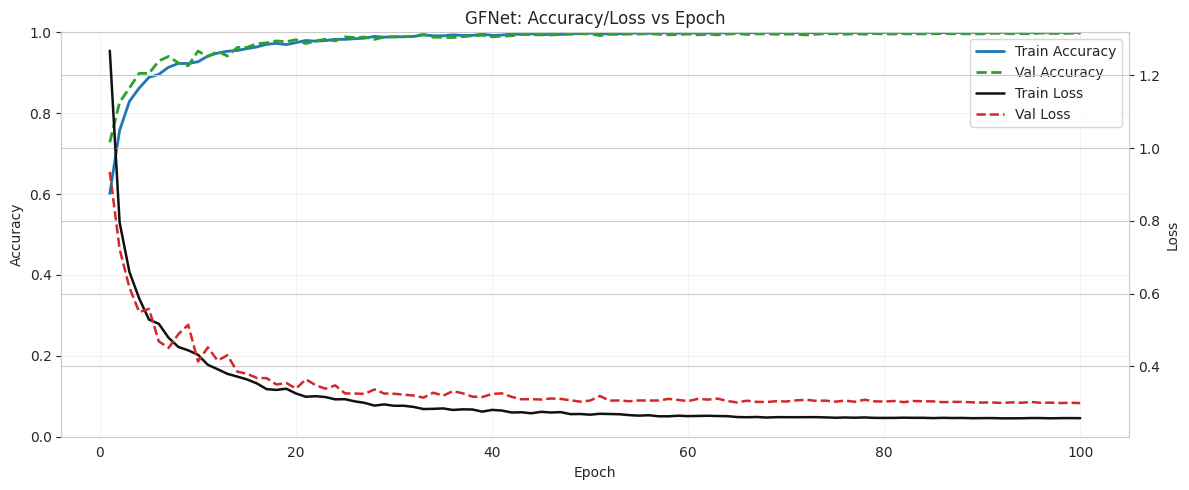

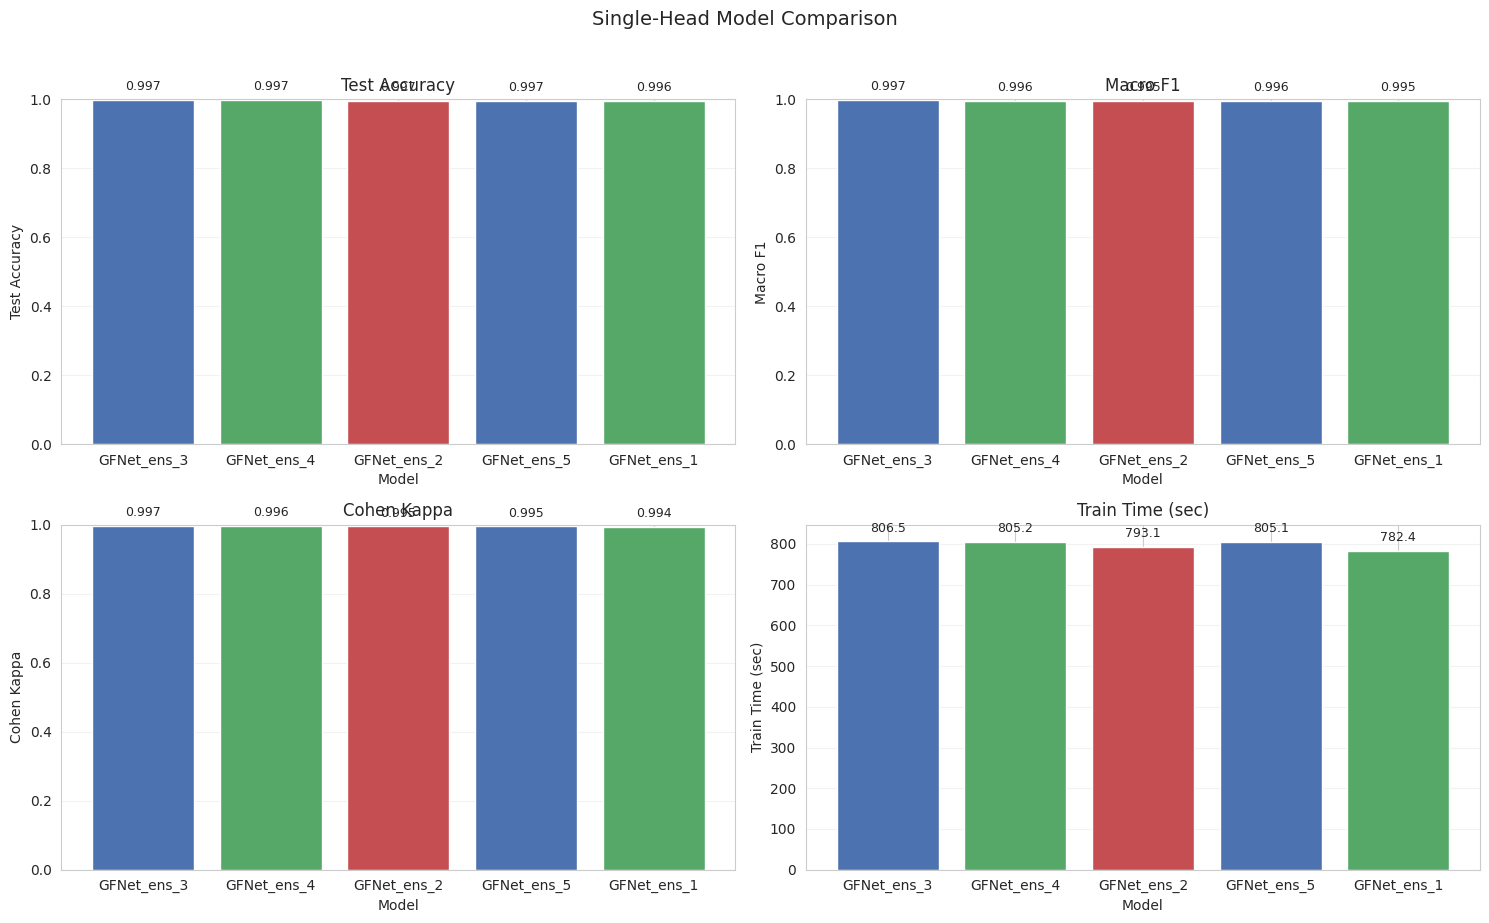

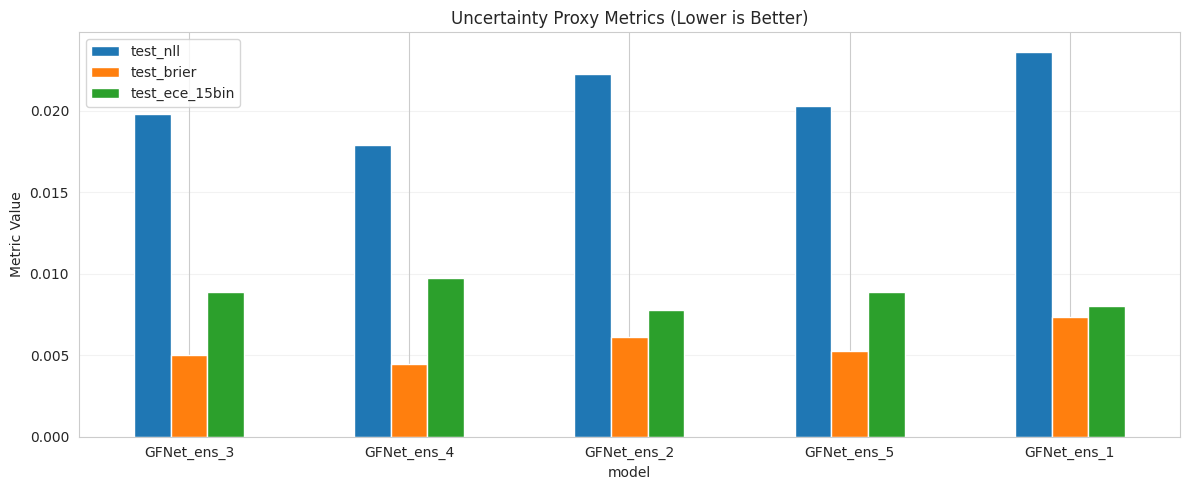

Saved training comparison plots to: /content/drive/My Drive/m_p/saved_models/training_plots


In [12]:
# -----------------------------
# Training curves + compact cross-model comparison
# -----------------------------
for model_name, artifact in model_artifacts.items():
    hist = artifact["history"]
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(epochs, hist["accuracy"], color="#1f77b4", linewidth=2, label="Train Accuracy")
    ax1.plot(epochs, hist["val_accuracy"], color="#2ca02c", linewidth=2, linestyle="--", label="Val Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(epochs, hist["loss"], color="#111111", linewidth=1.8, label="Train Loss")
    ax2.plot(epochs, hist["val_loss"], color="#d62728", linewidth=1.8, linestyle="--", label="Val Loss")
    ax2.set_ylabel("Loss")

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right", frameon=True)
    plt.title(f"{model_name}: Accuracy/Loss vs Epoch")
    plt.tight_layout()

    curve_path = PLOT_DIR / f"{model_name}_training_curves.png"
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_df = summary_df[[
    "model",
    "test_accuracy",
    "macro_f1",
    "kappa",
    "train_time_sec",
    "test_nll",
    "test_brier",
    "test_ece_15bin",
]].copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

metric_specs = [
    ("test_accuracy", "Test Accuracy", (0.0, 1.0), "{:.3f}"),
    ("macro_f1", "Macro F1", (0.0, 1.0), "{:.3f}"),
    ("kappa", "Cohen Kappa", (0.0, 1.0), "{:.3f}"),
    ("train_time_sec", "Train Time (sec)", None, "{:.1f}"),
]

palette = ["#4c72b0", "#55a868", "#c44e52"]
for ax, (col, title, ylim, fmt) in zip(axes, metric_specs):
    local = plot_df[["model", col]].copy()
    bars = ax.bar(local["model"], local[col], color=palette[: len(local)])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.25)
    for patch in bars:
        height = patch.get_height()
        x = patch.get_x() + patch.get_width() / 2
        offset = (ylim[1] - ylim[0]) * 0.02 if ylim is not None else max(local[col].max() * 0.02, 0.05)
        ax.text(x, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=9)

plt.suptitle("Single-Head Model Comparison", y=1.02, fontsize=14)
plt.tight_layout()
comparison_path = PLOT_DIR / "model_comparison_metrics.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

# Calibration proxy chart for uncertainty readiness
fig, ax = plt.subplots(figsize=(12, 5))
calib_cols = ["test_nll", "test_brier", "test_ece_15bin"]
calib_df = plot_df[["model"] + calib_cols].set_index("model")
calib_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Uncertainty Proxy Metrics (Lower is Better)")
ax.set_ylabel("Metric Value")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
calib_path = PLOT_DIR / "uncertainty_proxy_metrics.png"
plt.savefig(calib_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved training comparison plots to:", PLOT_DIR)




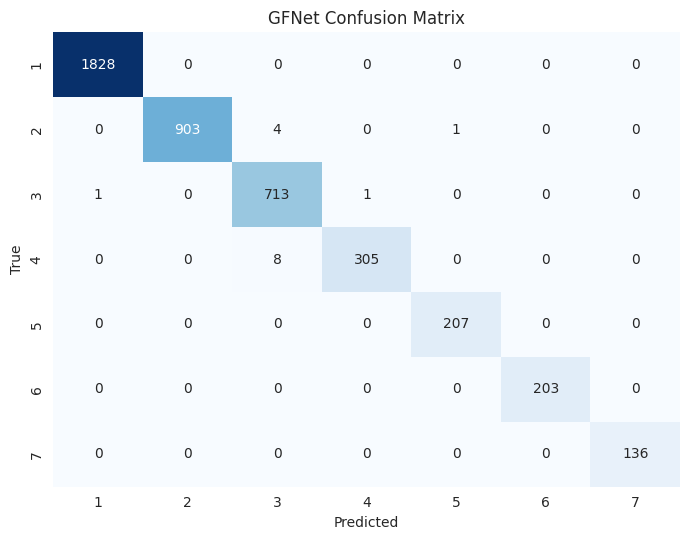

Saved confusion matrix figure: /content/drive/My Drive/m_p/saved_models/training_plots/confusion_matrices_side_by_side.png


In [13]:
# -----------------------------
# Confusion matrices side-by-side
# -----------------------------
class_ticks = [str(i + 1) for i in range(num_classes)]
fig, axes = plt.subplots(1, len(model_artifacts), figsize=(7 * len(model_artifacts), 5.5))

if len(model_artifacts) == 1:
    axes = [axes]

for ax, (model_name, artifact) in zip(axes, model_artifacts.items()):
    sns.heatmap(
        artifact["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_ticks,
        yticklabels=class_ticks,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
cm_path = PLOT_DIR / "confusion_matrices_side_by_side.png"
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved confusion matrix figure:", cm_path)




## Visualisation and Classification Image

In [14]:
# -----------------------------
# Optional: load saved model later
# -----------------------------
CUSTOM_OBJECTS = {
    "PatchExtractor": PatchExtractor,
    "PatchPositionEncoder": PatchPositionEncoder,
    "GlobalFilterLayer": GlobalFilterLayer,
    "PatchEncoderWithCLS": PatchEncoderWithCLS,
}

# Example:
example_path = MODEL_DIR / "ViT_UNet_final.keras"
if example_path.exists():
    loaded_model = keras.models.load_model(
        example_path,
        custom_objects=CUSTOM_OBJECTS,
        compile=False,
        safe_mode=False,
    )
    print("Loaded:", example_path)
    print("Model name:", loaded_model.name)
else:
    print("Example model not found yet. Train first, then reload.")




Loaded: /content/drive/My Drive/m_p/saved_models/ViT_UNet_final.keras
Model name: ViT_UNet_SingleHead


In [15]:
# -----------------------------
# Visualization save imports
# -----------------------------
import io
from matplotlib.colors import ListedColormap
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage





In [16]:
# -----------------------------
# Scene visualization helpers
# -----------------------------
VIS_DIR = RESULTS_DIR / "scene_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

VIS_EXCEL_PATH = VIS_DIR / "initial_classification_maps.xlsx"

# CLASS_COLOR_BASE = [
#     "#0000FF",  # Blue
#     "#00FF00",  # Green
#     "#FF0000",  # Red
#     "#00FFFF",  # Cyan
#     "#FF00FF",  # Magenta
#     "#FFFF00",  # Yellow
#     "#A52A2A",  # Brown
#     "#FFA500",
#     "#7FFF00",
#     "#8A2BE2",
# ]
BACKGROUND_COLOR = "#000000"


def get_scene_rgb(x_img, bands):
    if bands >= 6:
        rgb_idx = [bands // 2 - 1, bands // 2, bands // 2 + 1]
    elif bands >= 3:
        rgb_idx = [0, 1, 2]
    else:
        raise ValueError(f"Need at least 3 bands to form RGB, got {bands}.")
    return np.clip(x_img[:, :, rgb_idx], 0.0, 1.0)


def get_display_cmap(num_classes):
    return ListedColormap([BACKGROUND_COLOR] + CLASS_COLOR_BASE[:num_classes])


def predict_full_scene_labels(model, x_img, patch_size=9, batch_size=256):
    pad = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode="edge")
    preds = np.zeros((x_img.shape[0], x_img.shape[1]), dtype=np.int32)

    for r in range(x_img.shape[0]):
        row_patches = np.empty(
            (x_img.shape[1], patch_size, patch_size, x_img.shape[-1]),
            dtype=np.float32,
        )
        for c in range(x_img.shape[1]):
            row_patches[c] = x_pad[r:r + patch_size, c:c + patch_size, :]

        row_prob = model.predict(row_patches, batch_size=batch_size, verbose=0)
        preds[r] = np.argmax(row_prob, axis=1) + 1  # back to 1..K

    return preds


def load_models_for_visualization(model_dir, custom_objects):
    model_files = {
        "AlexNet_CNN": model_dir / "AlexNet_CNN_best.keras",
        "GFNet": model_dir / "GFNet_best.keras",
        "ViT_UNet": model_dir / "ViT_UNet_best.keras",
    }

    loaded = {}
    missing = {}

    for model_key, model_path in model_files.items():
        if not model_path.exists():
            missing[model_key] = f"Missing file: {model_path}"
            continue

        try:
            loaded[model_key] = keras.models.load_model(
                model_path,
                custom_objects=custom_objects,
                compile=False,
                safe_mode=False,
            )
        except Exception as exc:
            missing[model_key] = f"Load failed: {exc}"

    return loaded, missing


def save_single_panel(image, title, save_path, cmap=None, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    if cmap is None:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_combined_overview(rgb_image, y_true, pred_maps, missing_info, num_classes, save_path):
    cmap = get_display_cmap(num_classes)

    panels = [
        ("Approximate RGB", rgb_image, "rgb"),
        ("True Label Map", y_true, "label"),
        ("AlexNet Initial Classification", pred_maps.get("AlexNet_CNN"), "label"),
        ("GFNet Initial Classification", pred_maps.get("GFNet"), "label"),
        ("ViT Initial Classification", pred_maps.get("ViT_UNet"), "label"),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(30, 7), sharex=True, sharey=True)

    for ax, (title, img, kind) in zip(axes, panels):
        ax.set_title(title, fontsize=13)

        if kind == "rgb":
            ax.imshow(img)
        else:
            if img is None:
                ax.imshow(np.zeros_like(y_true), cmap=cmap, vmin=0, vmax=num_classes)
                key = None
                if "AlexNet" in title:
                    key = "AlexNet_CNN"
                elif "GFNet" in title:
                    key = "GFNet"
                elif "ViT" in title:
                    key = "ViT_UNet"
                ax.text(
                    0.5,
                    0.5,
                    missing_info.get(key, "Unavailable"),
                    ha="center",
                    va="center",
                    fontsize=10,
                    wrap=True,
                    transform=ax.transAxes,
                )
            else:
                ax.imshow(img, cmap=cmap, vmin=0, vmax=num_classes)

        ax.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, color=BACKGROUND_COLOR, label="Background")]
    for i in range(num_classes):
        handles.append(
            plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOR_BASE[i], label=f"Class {i+1}")
        )

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=min(num_classes + 1, 8),
        bbox_to_anchor=(0.5, -0.02),
        frameon=True,
    )
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_images_to_excel(excel_path, image_paths, sheet_name="Initial_Classification_Maps"):
    if excel_path.exists():
        wb = load_workbook(excel_path)
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]
        ws = wb.create_sheet(title=sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    anchors = ["A1", "J1", "A25", "J25", "A49", "J49"]
    for path, anchor in zip(image_paths, anchors):
        if path.exists():
            img = XLImage(str(path))
            img.anchor = anchor
            ws.add_image(img)

    wb.save(excel_path)
    print("Saved Excel workbook:", excel_path)





In [17]:
f# -----------------------------
# Load saved models, generate maps, save PNGs and Excel
# -----------------------------
VIS_CUSTOM_OBJECTS = {
    "PatchExtractor": PatchExtractor,
    "PatchPositionEncoder": PatchPositionEncoder,
    "GlobalFilterLayer": GlobalFilterLayer,
    "PatchEncoderWithCLS": PatchEncoderWithCLS,
}

scene_rgb = get_scene_rgb(x_img, B)
display_cmap = get_display_cmap(num_classes)

loaded_models, missing_models = load_models_for_visualization(MODEL_DIR, VIS_CUSTOM_OBJECTS)
prediction_maps = {}

for model_key, loaded_model in loaded_models.items():
    print(f"Generating full-scene classified image for {model_key}...")
    prediction_maps[model_key] = predict_full_scene_labels(
        loaded_model,
        x_img,
        patch_size=PATCH_SIZE,
        batch_size=BATCH_SIZE,
    )
    print(f"{model_key} map shape:", prediction_maps[model_key].shape)

if missing_models:
    print("Some models could not be loaded:")
    for model_key, reason in missing_models.items():
        print(f" - {model_key}: {reason}")

# Save individual PNGs
rgb_png = VIS_DIR / "scene_rgb.png"
gt_png = VIS_DIR / "ground_truth_label_map.png"
alex_png = VIS_DIR / "AlexNet_CNN_initial_classification.png"
gfnet_png = VIS_DIR / "GFNet_initial_classification.png"
vit_png = VIS_DIR / "ViT_UNet_initial_classification.png"
overview_png = VIS_DIR / "combined_initial_classification_overview.png"

save_single_panel(scene_rgb, "Approximate RGB", rgb_png)
save_single_panel(y_img, "Ground Truth Label Map", gt_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("AlexNet_CNN") is not None:
    save_single_panel(
        prediction_maps["AlexNet_CNN"],
        "AlexNet Initial Classification",
        alex_png,
        cmap=display_cmap,
        vmin=0,
        vmax=num_classes,
    )

if prediction_maps.get("GFNet") is not None:
    save_single_panel(
        prediction_maps["GFNet"],
        "GFNet Initial Classification",
        gfnet_png,
        cmap=display_cmap,
        vmin=0,
        vmax=num_classes,
    )

if prediction_maps.get("ViT_UNet") is not None:
    save_single_panel(
        prediction_maps["ViT_UNet"],
        "ViT Initial Classification",
        vit_png,
        cmap=display_cmap,
        vmin=0,
        vmax=num_classes,
    )

# Save combined overview PNG
save_combined_overview(
    rgb_image=scene_rgb,
    y_true=y_img,
    pred_maps=prediction_maps,
    missing_info=missing_models,
    num_classes=num_classes,
    save_path=overview_png,
)

# Save PNGs into Excel workbook
image_paths_for_excel = [rgb_png, gt_png, alex_png, gfnet_png, vit_png, overview_png]
save_images_to_excel(VIS_EXCEL_PATH, image_paths_for_excel, sheet_name="Initial_Classification_Maps")

print("All visualization outputs saved in:", VIS_DIR)





Output hidden; open in https://colab.research.google.com to view.